# 🔋 Stochastic Battery Optimization Routine Demonstration

This notebook demonstrates the mathematical optimization routine used in the `BatteryOpt` platform.
We will:
1. Generate synthetic, realistic residential electricity profiles (load, solar, and prices).
2. Generate stochastic intraday price scenario paths using our fitted **AR(1)-GARCH(1,1)** process.
3. Formulate and solve the Single-Stage Stochastic Pyomo model using the **IPOPT** solver.
4. Visualize the optimal battery dispatch schedule and grid exchange plan.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyomo.environ as pyo

# Add the backend source folder to the system path
sys.path.append(os.path.abspath("../backend/src"))

from optimization.model_factory import (
    create_microgrid_model,
    BatteryParams,
    Hyperparameters,
    generate_garch_scenarios
)
from optimization.solver import run_optimization_and_get_results

sns.set_theme(style="whitegrid")
print('✅ Imports loaded successfully!')

✅ Imports loaded successfully!


## 1. Synthetic Data Generation 📊

We generate 24 hours of standard residential weather/solar, load, and day-ahead electricity prices to use as the base inputs for our model.

In [2]:
# Generate 24 hours of data
times = pd.date_range(start="2026-06-22 00:00:00", periods=24, freq="h")

# 1. Base Day-Ahead Price Profile in USD/kWh (morning and evening peaks)
base_prices = [
    0.05, 0.04, 0.04, 0.04, 0.05, 0.08, # Night / Early Morning
    0.12, 0.15, 0.14, 0.10, 0.08, 0.07, # Morning peak & midday drop
    0.06, 0.07, 0.09, 0.11, 0.16, 0.18, # Midday solar drop & evening peak
    0.15, 0.12, 0.10, 0.08, 0.06, 0.05  # Night slide
]

# 2. Solar PV Profile in kW (bell curve peaking at 12:00)
solar_profile = [
    0.0, 0.0, 0.0, 0.0, 0.0, 0.1,
    0.5, 1.2, 2.2, 3.1, 3.8, 4.0,
    3.8, 3.2, 2.3, 1.3, 0.6, 0.1,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0
]

# 3. Load Profile in kW (typical residential dual peak)
load_profile = [
    0.5, 0.4, 0.4, 0.4, 0.5, 0.8,
    1.5, 2.0, 1.8, 1.2, 1.0, 0.9,
    0.8, 0.9, 1.1, 1.5, 2.2, 2.8,
    2.5, 1.8, 1.2, 0.8, 0.6, 0.5
]

df = pd.DataFrame(index=times)
df["price_buy"] = base_prices
df["price_sell"] = df["price_buy"] * 0.9
df["solar_kw"] = solar_profile
df["load_kw"] = load_profile

print('--- Generated Input Data Preview ---')
print(df.head())


--- Generated Input Data Preview ---
                     price_buy  price_sell  solar_kw  load_kw
2026-06-22 00:00:00       0.05       0.045       0.0      0.5
2026-06-22 01:00:00       0.04       0.036       0.0      0.4
2026-06-22 02:00:00       0.04       0.036       0.0      0.4
2026-06-22 03:00:00       0.04       0.036       0.0      0.4
2026-06-22 04:00:00       0.05       0.045       0.0      0.5


## 2. Stochastic Intraday Scenario Generation with GARCH 🧪

Using the pre-estimated **AR(1)-GARCH(1,1)** model, we generate 10 price spread paths and add them to the base day-ahead prices to simulate intraday volatility scenarios.

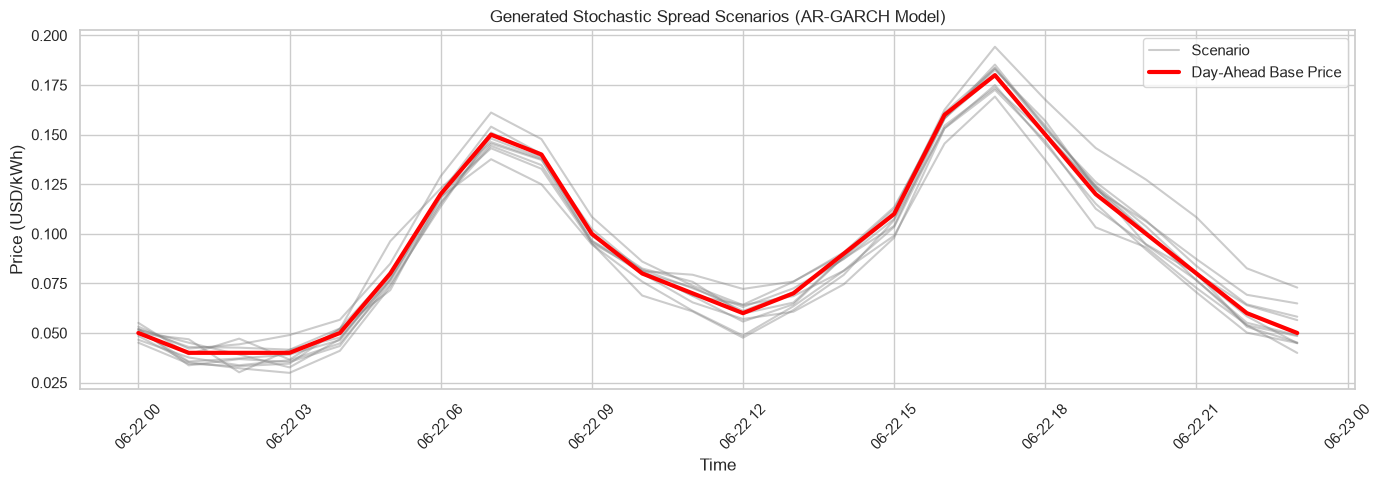

In [3]:
# Generate GARCH scenarios
n_scenarios = 10
np.random.seed(42)
spreads = generate_garch_scenarios(len(times), n_scenarios=n_scenarios)

plt.figure(figsize=(14, 5))
for s in range(n_scenarios):
    plt.plot(df.index, df["price_buy"] + spreads[:, s], color='gray', alpha=0.4, label='Scenario' if s == 0 else "")
plt.plot(df.index, df["price_buy"], color='red', linewidth=3, label='Day-Ahead Base Price')
plt.title(f'Generated Stochastic Spread Scenarios (AR-GARCH Model)')
plt.xlabel("Time")
plt.ylabel("Price (USD/kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Solve the Stochastic Microgrid Optimization 🚀

Next, we initialize battery parameters, set the degradation penalty coefficient ($\alpha$) and grid transaction fee, and solve the stochastic model.

In [4]:
# Physical battery specs
battery_params = BatteryParams(
    max_capacity_kwh=10.0,
    max_power_kw=3.0,
    efficiency_charge=0.95,
    efficiency_discharge=0.95,
    initial_soc_kwh=2.0
)

# Optimization parameters
hyper_params = Hyperparameters(
    alpha=0.001,  # Non-linear battery degradation penalty
    grid_fee=0.01  # Grid network usage fee
)

# Build Stochastic Model
model = create_microgrid_model(
    time_series=df,
    battery_params=battery_params,
    hyper_params=hyper_params,
    n_scenarios=n_scenarios
)

# Run IPOPT Solver
results_df = run_optimization_and_get_results(model)

Starting the IPOPT Solver...

✅ Optimal Solution Found! Extracting results...
Total Minimized Expected Cost: $-0.30



## 4. Dispatch Schedule Visualization 📈

We plot the optimized charge/discharge powers, grid import/export schedules, state of charge (SoC), and the day-ahead prices to visualize how the system optimizes dispatch.

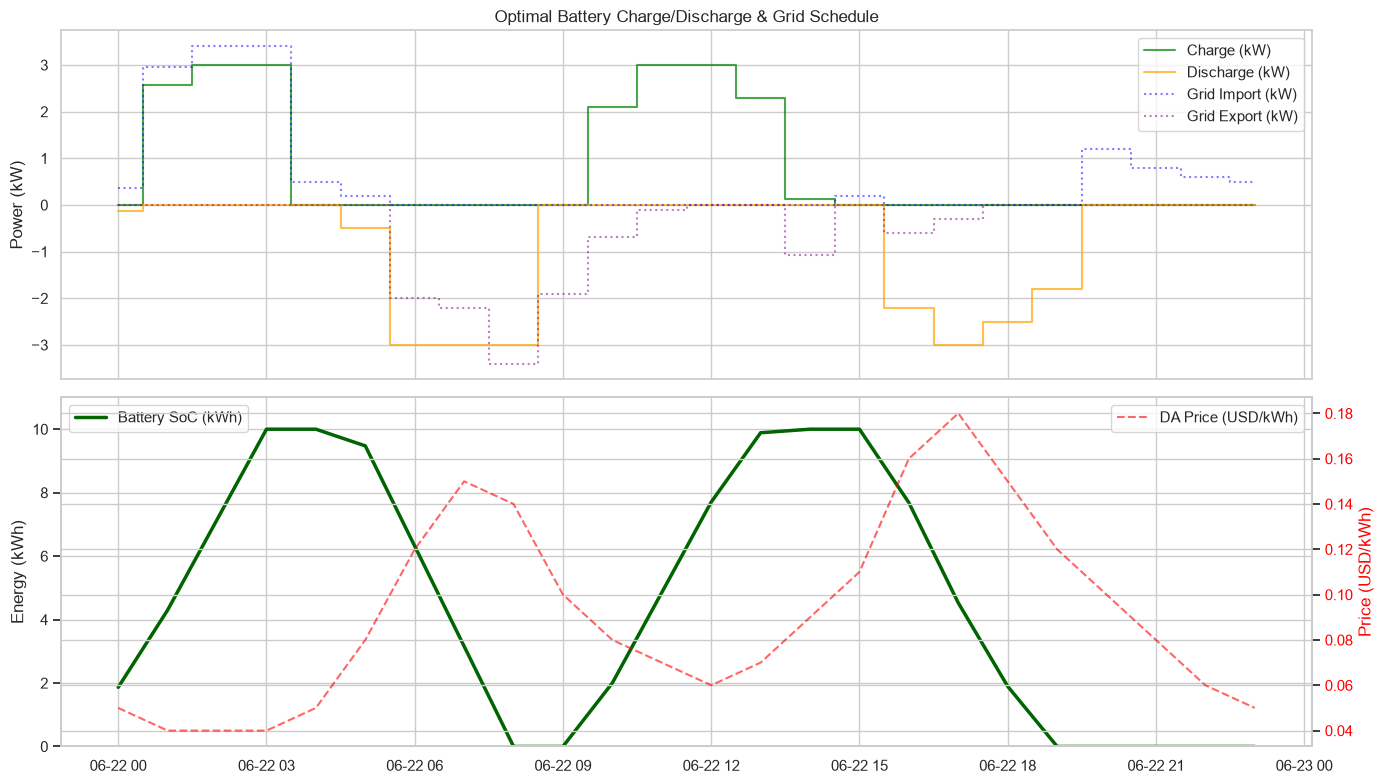

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Subplot 1: Power flows
ax1.step(results_df.index, results_df["p_charge_kw"], where='mid', label="Charge (kW)", color="green", alpha=0.7)
ax1.step(results_df.index, -results_df["p_discharge_kw"], where='mid', label="Discharge (kW)", color="orange", alpha=0.7)
ax1.step(results_df.index, results_df["p_buy_kw"], where='mid', label="Grid Import (kW)", color="blue", alpha=0.5, linestyle=":")
ax1.step(results_df.index, -results_df["p_sell_kw"], where='mid', label="Grid Export (kW)", color="purple", alpha=0.5, linestyle=":")
ax1.set_ylabel("Power (kW)")
ax1.title.set_text("Optimal Battery Charge/Discharge & Grid Schedule")
ax1.legend()

# Subplot 2: SoC & Prices
ax2.plot(results_df.index, results_df["soc_kwh"], label="Battery SoC (kWh)", color="darkgreen", linewidth=2.5)
ax2.set_ylabel("Energy (kWh)")
ax2.set_ylim(0, 11)
ax2.legend(loc="upper left")

# Share secondary axis for price buy
ax2_price = ax2.twinx()
ax2_price.plot(results_df.index, results_df["price_buy_usd"], label="DA Price (USD/kWh)", color="red", alpha=0.6, linestyle="--")
ax2_price.set_ylabel("Price (USD/kWh)", color="red")
ax2_price.tick_params(axis='y', labelcolor="red")
ax2_price.legend(loc="upper right")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Constraint Verification & Economic Performance 🔍

We verify the node power balance at every timestamp to guarantee physical correctness, and compare the expected cost of running the microgrid with vs. without battery optimization.

In [6]:
# 1. Verify Node Balance
input_power = results_df["solar_kw"] + results_df["p_buy_kw"] + results_df["p_discharge_kw"]
output_power = results_df["load_kw"] + results_df["p_sell_kw"] + results_df["p_charge_kw"]
max_diff = (input_power - output_power).abs().max()
print(f'Max Discrepancy in Node Power Balance Constraint: {max_diff:.2e} kW')

# 2. Calculate Economics
# Without battery: net exchange is (load - solar). Import if positive, export if negative.
net_no_battery = df["load_kw"] - df["solar_kw"]
da_price_buy = df["price_buy"]
da_price_sell = df["price_sell"]

cost_no_battery = 0
for t in df.index:
    net_flow = net_no_battery.loc[t]
    if net_flow > 0:
        cost_no_battery += (net_flow * da_price_buy.loc[t] + hyper_params.grid_fee * net_flow)
    else:
        cost_no_battery += (net_flow * da_price_sell.loc[t] + hyper_params.grid_fee * abs(net_flow))

optimized_cost = pyo.value(model.cost)

print(f'\n--- 💵 Economic Results Summary ---')
print(f'Expected cost without Battery: ${cost_no_battery:.2f}')
print(f'Expected optimized cost with Battery: ${optimized_cost:.2f}')
print(f'Saved: ${cost_no_battery - optimized_cost:.2f} ({((cost_no_battery - optimized_cost)/cost_no_battery)*100:.1f}%)')


Max Discrepancy in Node Power Balance Constraint: 4.44e-16 kW

--- 💵 Economic Results Summary ---
Expected cost without Battery: $1.28
Expected optimized cost with Battery: $-0.30
Saved: $1.58 (123.1%)
